## Setup

First, let's set up the Python environment and import necessary libraries.

In [1]:
# Configure loguru FIRST to suppress verbose logging in notebooks only
import sys
import os
from loguru import logger
logger.remove()  # Remove default handler

# Add filter to suppress tech_adoption warnings
def filter_tech_warnings(record):
    return not any(msg in record["message"] for msg in [
        "No data found for technology",
        "No growth data available"
    ])

logger.add(sys.stderr, level='WARNING', format='<level>{level: <8}</level> | <cyan>{name}</cyan>:<cyan>{function}</cyan>:<cyan>{line}</cyan> - <level>{message}</level>', filter=filter_tech_warnings)

from pathlib import Path

# Get the BICEP root directory (three levels up from this notebook)
bicep_root = Path.cwd().parent.parent.parent
if str(bicep_root) not in sys.path:
    sys.path.insert(0, str(bicep_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 150

from bicep.analysis import BicepResults, BicepMultiStateResults

print("Environment setup complete!")

Environment setup complete!


In [2]:
import os

# SUPPRESS LOGGING FOR CLEAN NOTEBOOK OUTPUT
# To see full BICEP logging details, comment out the line below:
os.environ['LOGURU_LEVEL'] = 'WARNING'

## Data Sources Used in BICEP

BICEP uses illustrative datasets from several open-source models and frameworks. This documentation uses these illustrative datasets to demonstrate BICEP functionality. **The BICEP tool is intended to be run on any arbitrary technology time series projection.** If you want to use your own technology forecast, you can bring your own.

### Building Stock Data Sources

**BICEP uses data from ResStock and ComStock models:**

- [ResStock](https://nrel.github.io/ResStock.github.io/) [1] - Residential building energy consumption estimates for ~880,000 representative US houses
- [ComStock](https://www.nrel.gov/docs/fy23osti/83819.pdf) [2] - Commercial building energy consumption estimates for ~180,000 representative US commercial buildings

These models provide detailed building characteristics including:
- Building type, age, size, location
- End-use consumption profiles (heating, cooling, water heating, etc.)
- Peak electrical load estimates

### Technology Adoption Forecast Sources

**For our illustrative scenarios, we use forecasts from:**

1. **[Scout Model](https://scout-bto.readthedocs.io/)** [3] - Building sector technology adoption forecasts for heat pumps and heat pump water heaters
2. **[ReEDS Model](https://doi.org/10.2172/1788425)** [4] - Electricity sector solar photovoltaic capacity forecasts by region
3. **[TEMPO Model](https://doi.org/10.2172/1823026)** [5] - Transportation sector electric vehicle adoption projections

**Two Scenarios:**
- **BAU (Business-As-Usual):** Conservative technology adoption aligned with stated policies
- **High Electrification:** Accelerated technology adoption for aggressive climate goals

### Minimum Data Requirements

**To use BICEP with your own technology forecasts, you only need:**

- **Base Year (e.g., 2020):** Stock count for each technology
- **End Year (e.g., 2050):** Projected stock count for each technology
- **Geographic aggregation level:** State, utility territory, or custom region

BICEP will interpolate between base and end years to create adoption trajectories.

## About These Datasets

**Illustrative Data Notice:** The datasets and technology adoption forecasts presented in this documentation are for illustrative purposes only and represent a snapshot of model outputs. The data is not updated in real-time and should not be used for actual planning without verification.

**TEMPO Dataset Note:** For electric vehicle charging infrastructure, we reference projections from the [TEMPO Project](https://doi.org/10.2172/1823026) [5], which provides county-level EV charging demand estimates based on vehicle adoption forecasts.

**Key Characteristics of BICEP Datasets:**

- Data spans 2020-2050 to capture long-term technology adoption trends
- Building-level analysis with aggregation to state level
- Covers residential, commercial, and public EV charging sectors
- Probabilistic cost estimates reflecting uncertainty in upgrade requirements

In [3]:
# Create a technologies overview
technologies = {
    'Technology': [
        'Electric Vehicles (EV)',
        'Heat Pumps (HP)',
        'Heat Pump Water Heaters (HPWH)',
        'Solar Photovoltaic (PV)'
    ],
    'End Use': [
        'Transportation',
        'Space Heating/Cooling',
        'Water Heating',
        'Electricity Generation'
    ],
    'Typical Amperage': [
        '50 A (Level 2 charger)',
        '30-60 A',
        '20-30 A',
        'Variable (reduces net load)'
    ],
    'Scenarios Available': [
        'BAU, High',
        'BAU, High',
        'BAU, High',
        'BAU, High'
    ]
}

tech_df = pd.DataFrame(technologies)
print("Technologies Analyzed by BICEP:")
print(tech_df.to_string(index=False))

Technologies Analyzed by BICEP:
                    Technology                End Use            Typical Amperage Scenarios Available
        Electric Vehicles (EV)         Transportation      50 A (Level 2 charger)           BAU, High
               Heat Pumps (HP)  Space Heating/Cooling                     30-60 A           BAU, High
Heat Pump Water Heaters (HPWH)          Water Heating                     20-30 A           BAU, High
       Solar Photovoltaic (PV) Electricity Generation Variable (reduces net load)           BAU, High


## Technology Adoption Across Scenarios

Let's compare how technology adoption differs between the BAU (Business As Usual) and High Demand Growth scenarios.


## Example Technology Adoption Forecasts

Below are examples of what technology adoption forecasts look like in BICEP. These illustrative forecasts show the typical trajectory from a base year to an end year.


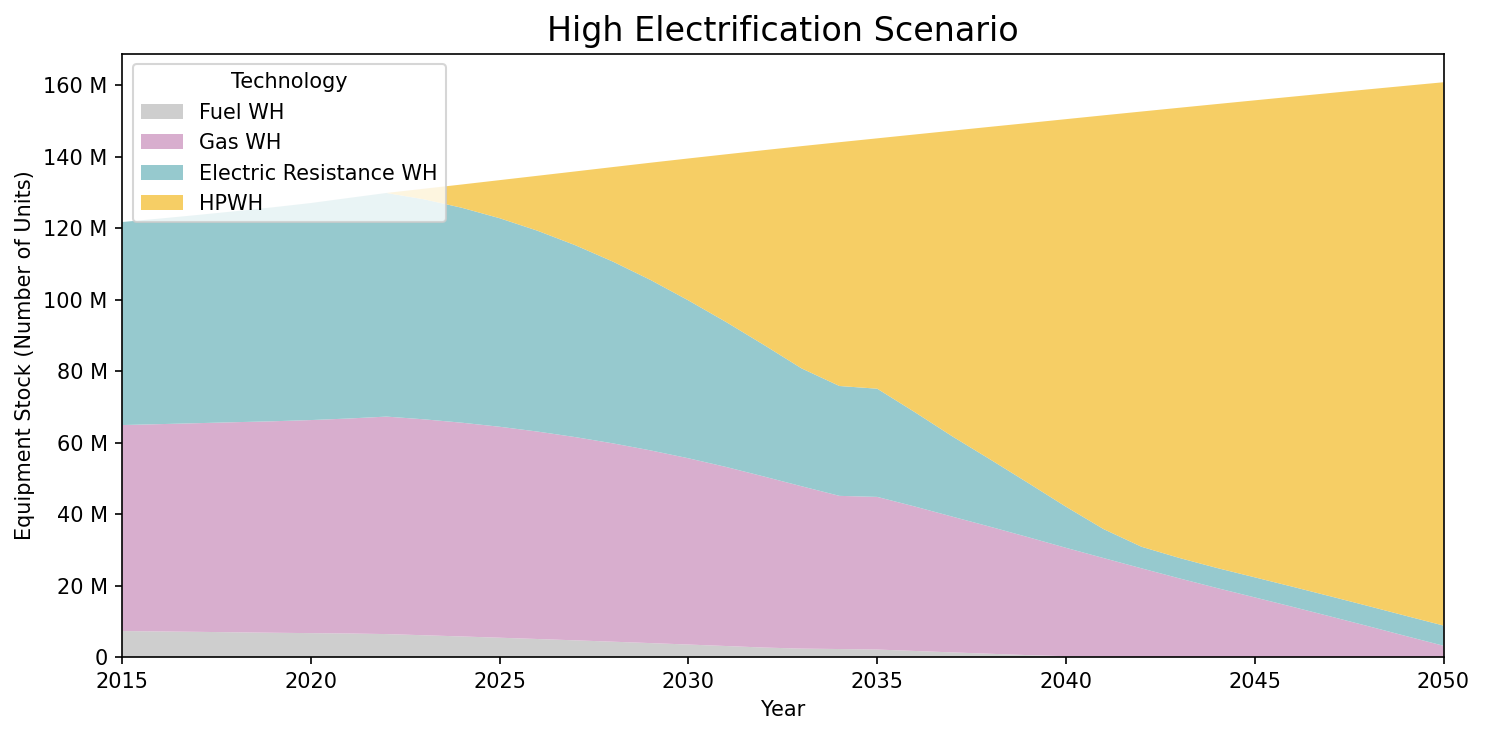


This chart shows adoption forecast data from BICEP.
Data spans 2015-2050 with 36 time points.
Total 2050 water heater stock: 160,907,299 units


In [4]:
# Load real adoption forecast data from BICEP
adoption_data = pd.read_parquet(bicep_root / 'data' / 'adoption-forecasts.parquet')

# Filter for water heater technologies in high scenario
wh_techs = ['hpwh', 'electric wh', 'gas wh', 'fuel wh']
wh_data = adoption_data[
    (adoption_data['tech_name'].isin(wh_techs)) & 
    (adoption_data['scenario'] == 'high')
]

# Aggregate stock projections by year and technology (sum across all states)
wh_agg = wh_data.groupby(['year', 'tech_name'])['stock_projection'].sum().unstack(fill_value=0)

# Reorder columns to match desired stacking order
wh_agg = wh_agg[['hpwh', 'electric wh', 'gas wh', 'fuel wh']]

years = wh_agg.index.values

# Create stacked area plot with matplotlib
colors = {'hpwh': '#f6c954', 'electric wh': '#8bc4c9', 'gas wh': '#d4a5c9', 'fuel wh': '#c9c9c9'}
labels = {'hpwh': 'HPWH', 'electric wh': 'Electric Resistance WH', 'gas wh': 'Gas WH', 'fuel wh': 'Fuel WH'}

stack_order = ['fuel wh', 'gas wh', 'electric wh', 'hpwh']

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(
    years,
    *[wh_agg[tech].values for tech in stack_order],
    labels=[labels[tech] for tech in stack_order],
    colors=[colors[tech] for tech in stack_order],
    alpha=0.9
)

ax.set_title('High Electrification Scenario', fontsize=16)
ax.set_xlabel('Year')
ax.set_ylabel('Equipment Stock (Number of Units)')
ax.set_xlim(years.min(), years.max())
ax.yaxis.set_major_formatter(mticker.EngFormatter())
ax.legend(title='Technology', loc='upper left')
plt.tight_layout()
plt.show()

print("\nThis chart shows adoption forecast data from BICEP.")
print(f"Data spans {years.min()}-{years.max()} with {len(years)} time points.")
print(f"Total 2050 water heater stock: {wh_agg.loc[2050].sum():,.0f} units")

In [5]:
# Run both scenarios from SQLite database
print("Running BAU scenario analysis for all US states...")
bau_all = BicepMultiStateResults(scenario='bau', mode='local', target_states='all')
bau_res = bau_all.all_states_buildings

print("\nRunning High scenario analysis for all US states...")
high_all = BicepMultiStateResults(scenario='high', mode='local', target_states='all')
high_res = high_all.all_states_buildings

print(f"\nBAU buildings: {len(bau_res):,}")
print(f"High buildings: {len(high_res):,}")
print(f"\nScenarios loaded successfully.")


Running BAU scenario analysis for all US states...


/Users/faye994/code/BICEP/bicep/capacity.py:329: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg['represented_vehicles'] = (bldg['total_units']/5).fillna(1) * bldg['total_parking_spaces']
/Users/faye994/code/BICEP/bicep/capacity.py:329: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg['represented_vehicles'] = (bldg['total_units']/5).fillna(1) * bldg['total_parking_spaces']



Running High scenario analysis for all US states...


/Users/faye994/code/BICEP/bicep/capacity.py:329: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg['represented_vehicles'] = (bldg['total_units']/5).fillna(1) * bldg['total_parking_spaces']
/Users/faye994/code/BICEP/bicep/capacity.py:329: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg['represented_vehicles'] = (bldg['total_units']/5).fillna(1) * bldg['total_parking_spaces']



BAU buildings: 884,596
High buildings: 884,596

Scenarios loaded successfully.


### Building Stock Analysis

Let's analyze the building characteristics in the BICEP dataset.

In [6]:
# Compare building characteristics between scenarios
print("\n" + "="*70)
print("BUILDING STOCK COMPARISON")
print("="*70)

print(f"\nBAU Scenario:")
print(f"  Total buildings: {len(bau_res):,}")
print(f"  Residential: {(bau_res['residential'] == 1).sum():,}")
print(f"  Commercial: {(bau_res['residential'] == 0).sum():,}")
print(f"  Average sqft: {bau_res['sqft'].mean():,.0f}")
print(f"  Total sqft: {bau_res['sqft'].sum():,.0f}")

print(f"\nHigh Scenario:")
print(f"  Total buildings: {len(high_res):,}")
print(f"  Residential: {(high_res['residential'] == 1).sum():,}")
print(f"  Commercial: {(high_res['residential'] == 0).sum():,}")
print(f"  Average sqft: {high_res['sqft'].mean():,.0f}")
print(f"  Total sqft: {high_res['sqft'].sum():,.0f}")

print(f"\n" + "="*70)
print("Building datasets contain full analysis results from BICEP,")
print("including capacity requirements and upgrade costs for all technologies.")
print("="*70)


BUILDING STOCK COMPARISON

BAU Scenario:
  Total buildings: 884,596
  Residential: 548,916
  Commercial: 335,680
  Average sqft: 16,348
  Total sqft: 14,461,110,921

High Scenario:
  Total buildings: 884,596
  Residential: 548,916
  Commercial: 335,680
  Average sqft: 16,348
  Total sqft: 14,461,110,921

Building datasets contain full analysis results from BICEP,
including capacity requirements and upgrade costs for all technologies.


In [7]:
# Analyze building distribution by state
print("\nBuildings by Top 10 States (BAU):")
state_dist = bau_res['state'].value_counts().head(10)
for state, count in state_dist.items():
    print(f"  {state}: {count:,}")

print("\nBuildings by Top 10 States (High):")
state_dist_high = high_res['state'].value_counts().head(10)
for state, count in state_dist_high.items():
    print(f"  {state}: {count:,}")

print("\nNote: Both scenarios have identical building distributions.")
print("The difference is in technology adoption assumptions.")


Buildings by Top 10 States (BAU):
  CA: 96,923
  TX: 70,900
  FL: 60,477
  NY: 52,628
  PA: 37,231
  OH: 35,841
  IL: 33,440
  MI: 30,584
  NC: 29,939
  GA: 27,843

Buildings by Top 10 States (High):
  CA: 96,923
  TX: 70,900
  FL: 60,477
  NY: 52,628
  PA: 37,231
  OH: 35,841
  IL: 33,440
  MI: 30,584
  NC: 29,939
  GA: 27,843

Note: Both scenarios have identical building distributions.
The difference is in technology adoption assumptions.


## About BICEP Data

The BICEP results datasets contain pre-calculated infrastructure upgrade requirements for all buildings.

In [8]:
# Show data summary
print("\nBICEP Results Data Summary:")
print(f"  Total records (BAU): {len(bau_res):,}")
print(f"  Total records (High): {len(high_res):,}")
print(f"\nKey data columns in results:")
for col in bau_res.columns:
    print(f"  - {col}")

print(f"The 'upgrade_required' column indicates whether infrastructure upgrade is required:")
print(f"  BAU upgrades needed: {(bau_res['upgrade_required'] == 1).sum():,} ({(bau_res['upgrade_required'] == 1).sum() / len(bau_res) * 100:.1f}%)")
print(f"  High upgrades needed: {(high_res['upgrade_required'] == 1).sum():,} ({(high_res['upgrade_required'] == 1).sum() / len(high_res) * 100:.1f}%)")

print(f"\nBoth scenarios have identical building stocks - the difference is in")
print(f"technology adoption assumptions, which drive upgrade requirements.")


BICEP Results Data Summary:
  Total records (BAU): 884,596
  Total records (High): 884,596

Key data columns in results:
  - building_id
  - residential
  - max_elec_consumption_kwh
  - timestamp
  - upgrade
  - state
  - file_path
  - release
  - sqft
  - weight
  - total_units
  - peak_kw
  - peak_amp
  - assumed_volt
  - utilization
  - est_capacity
  - req_capacity
  - installed_capacity
  - spare_capacity
  - hp_peak_diff_kwh
  - hpwh_peak_diff_kwh
  - hp_req_capacity_amp
  - hpwh_req_capacity_amp
  - pv_relative_size
  - pv_size_kw
  - pv_req_capacity_amp
  - total_parking_spaces
  - perc_ev_spaces
  - ev_spaces
  - represented_vehicles
  - ev_req_capacity_amp
  - ev_adopted
  - pv_adopted
  - hp_adopted
  - hpwh_adopted
  - net_capacity_diff_amp
  - required_add_capacity_amp
  - upgrade_required
  - upgrade_costs_base
  - location_factor
  - upgrade_costs
  - equiv_annual_cost
  - weighted_cost
The 'upgrade_required' column indicates whether infrastructure upgrade is required:


## Using Custom Technology Forecasts

BICEP is designed to work with forecasts from Scout [3] and ReEDS [4], but you can also integrate custom forecasts. Here's how you would approach this:

### Option 1: Modify Adoption Data Before BICEP Analysis

If you have custom adoption forecasts, you can replace the adoption columns in the residential/commercial DataFrames before analysis.

In [9]:
# Example: Working with custom adoption data
# This shows how you could inject custom forecasts

print("Example: How to integrate custom forecasts with BICEP data")
print("="*60)
print("\nStep 1: Load your custom adoption forecasts")
print("  custom_forecasts = pd.read_csv('my_forecasts.csv')")
print("\nStep 2: Merge with BICEP results by state")
print("  merged = bau_res.merge(custom_forecasts, on='state')")
print("\nStep 3: Modify the adoption columns")
print("  merged['ev_adopted'] = (merged['ev_adoption_rate'] > 0.5).astype(int)")
print("\nStep 4: Use the modified data for analysis")
print("  # Run BICEP analysis on merged data")

Example: How to integrate custom forecasts with BICEP data

Step 1: Load your custom adoption forecasts
  custom_forecasts = pd.read_csv('my_forecasts.csv')

Step 2: Merge with BICEP results by state
  merged = bau_res.merge(custom_forecasts, on='state')

Step 3: Modify the adoption columns
  merged['ev_adopted'] = (merged['ev_adoption_rate'] > 0.5).astype(int)

Step 4: Use the modified data for analysis
  # Run BICEP analysis on merged data


### Option 2: Provide Your Own Forecast File

If you have adoption forecasts in a CSV file, you can merge them with BICEP's building data:

In [10]:
# Example structure for custom adoption data
custom_forecast_structure = pd.DataFrame({
    'state': ['CA', 'CA', 'TX', 'TX'],
    'year': [2030, 2040, 2030, 2040],
    'ev_adoption_rate': [0.25, 0.60, 0.20, 0.50],  # Fraction of buildings
    'hp_adoption_rate': [0.30, 0.70, 0.25, 0.65],
    'hpwh_adoption_rate': [0.20, 0.50, 0.15, 0.45],
    'pv_adoption_rate': [0.15, 0.40, 0.10, 0.35]
})

print("Example format for custom adoption forecasts:")
print(custom_forecast_structure.to_string(index=False))

print("\n" + "="*60)
print("To use custom forecasts:")
print("="*60)
print("1. Prepare data in the format above (state, year, adoption rates)")
print("2. Load your CSV: custom_data = pd.read_csv('your_forecasts.csv')")
print("3. Merge with BICEP building data by state and year")
print("4. Use values in custom_data columns to override adoption columns")
print("5. Run BicepResults on the modified data")

Example format for custom adoption forecasts:
state  year  ev_adoption_rate  hp_adoption_rate  hpwh_adoption_rate  pv_adoption_rate
   CA  2030              0.25              0.30                0.20              0.15
   CA  2040              0.60              0.70                0.50              0.40
   TX  2030              0.20              0.25                0.15              0.10
   TX  2040              0.50              0.65                0.45              0.35

To use custom forecasts:
1. Prepare data in the format above (state, year, adoption rates)
2. Load your CSV: custom_data = pd.read_csv('your_forecasts.csv')
3. Merge with BICEP building data by state and year
4. Use values in custom_data columns to override adoption columns
5. Run BicepResults on the modified data


## Bringing Your Own Forecast Data

**Good news: BICEP makes it easy!** You only need to provide **two data points** per technology:

| Required Field | Description |
|----------------|-------------|
| **Base Year Stock (2020)** | Current number of installations |
| **End Year Stock (2050)** | Projected number of installations |

That's it! BICEP handles the interpolation between years automatically.

### What BICEP Does For You:
- Interpolates adoption trajectories between your two data points
- Applies adoption rates to the building stock
- Calculates infrastructure upgrade requirements
- Estimates costs based on capacity needs

MINIMUM DATA REQUIRED - JUST TWO TIME POINTS

Your forecast data:
state technology  base_year  end_year  base_stock  end_stock
   CA         EV       2020      2050      500000   12000000
   TX         EV       2020      2050      300000    8500000
   NY         EV       2020      2050      250000    6500000

HOW IT WORKS

1. BICEP reads your two data points (base_year and end_year)
2. BICEP creates adoption trajectory by linear interpolation
3. You get infrastructure upgrade costs for your scenario

Example: California EV interpolation
----------------------------------------------------------------------
  2020: 500,000 installations
  2030: 4,333,333 installations
  2040: 8,166,666 installations
  2050: 12,000,000 installations


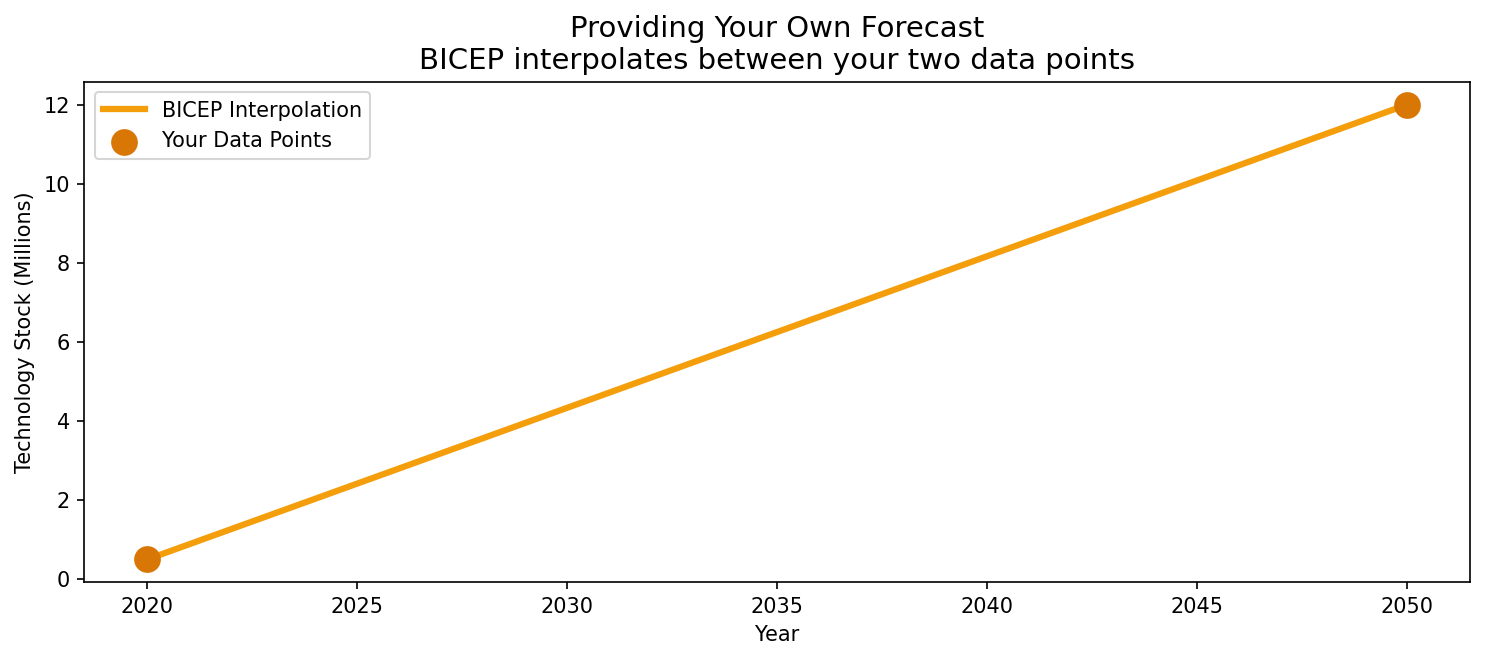


To run BICEP analysis please provide two years and BICEP handles the rest.


In [11]:
# Simple example: providing just two data points
import pandas as pd

# Your forecast data - JUST TWO YEARS NEEDED!
your_forecast = pd.DataFrame({
    'state': ['CA', 'TX', 'NY'],
    'technology': ['EV', 'EV', 'EV'],
    'base_year': [2020, 2020, 2020],
    'end_year': [2050, 2050, 2050],
    'base_stock': [500000, 300000, 250000],
    'end_stock': [12000000, 8500000, 6500000]
})

print("=" * 70)
print("MINIMUM DATA REQUIRED - JUST TWO TIME POINTS")
print("=" * 70)
print("\nYour forecast data:")
print(your_forecast.to_string(index=False))

print("\n" + "=" * 70)
print("HOW IT WORKS")
print("=" * 70)
print("\n1. BICEP reads your two data points (base_year and end_year)")
print("2. BICEP creates adoption trajectory by linear interpolation")
print("3. You get infrastructure upgrade costs for your scenario")

# Show how BICEP would interpolate
ca_base = 500000
ca_end = 12000000
ca_years = np.array([2020, 2030, 2040, 2050])
ca_interpolated = np.linspace(ca_base, ca_end, len(ca_years))

print("\nExample: California EV interpolation")
print("-" * 70)
for year, stock in zip(ca_years, ca_interpolated):
    print(f"  {int(year)}: {int(stock):,} installations")

# Visualization with matplotlib
ca_full_years = np.array([2020, 2025, 2030, 2035, 2040, 2045, 2050])
ca_full_interp = np.linspace(ca_base, ca_end, len(ca_full_years))

fig, ax = plt.subplots(figsize=(10, 4.5))

# BICEP interpolation line
ax.plot(ca_full_years, ca_full_interp / 1e6, color='#f59e0b', linewidth=3, label='BICEP Interpolation')

# User data points
ax.scatter([2020, 2050], [ca_base / 1e6, ca_end / 1e6], color='#d97706', s=140, zorder=5, label='Your Data Points')

ax.set_title('Providing Your Own Forecast\nBICEP interpolates between your two data points', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Technology Stock (Millions)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("To run BICEP analysis please provide two years and BICEP handles the rest.")
print("=" * 70)

## Summary

### Key Takeaways:

1. **BICEP analyzes 4 technologies**: EVs, Heat Pumps, HPWHs, and Solar PV
2. **Two scenarios are available**: BAU (lower adoption) and High (higher adoption)
3. **Technology adoption varies significantly**: The High scenario shows 2-3x higher adoption rates for heating technologies
4. **Custom forecasts can be integrated**: BICEP can work with your own adoption forecasts by merging data by state and year

### Next Steps:

- Explore the [Scenario Comparison](scenario-comparison.ipynb) notebook to see how these adoption differences affect infrastructure costs
- Check the [API Reference](../api-reference.html) for detailed method documentation
- Review the [Custom Distributions](custom-distributions.ipynb) notebook to learn about cost distributions

---

## References

[1] NREL. (2024). *ResStock General Reference Documentation.* National Renewable Energy Laboratory. https://nrel.github.io/ResStock.github.io/

[2] Parker, A., Henry, H., Horsey, H., Craig, M., et al. (2023). *ComStock Reference Documentation.* NREL/TP-5500-83819. https://www.nrel.gov/docs/fy23osti/83819.pdf

[3] Harris, C., Langevin, J., Roth, A., Phelan, P., Parker, A., Ball, B., et al. (2021). "Scout: An Impact Analysis Tool for Building Energy-Efficiency Technologies." *ACEEE Summer Study on Energy Efficiency in Buildings.* https://scout-bto.readthedocs.io/

[4] Ho, J., Becker, J., Brown, M., et al. (2021). *Regional Energy Deployment System (ReEDS) Model Documentation: Version 2020.* NREL/TP-6A20-78195. https://doi.org/10.2172/1788425

[5] Muratori, M., Jadun, P., Bush, B., et al. (2021). *The Transportation Energy and Mobility Pathway Options (TEMPO) Model.* NREL/TP-5400-80306. https://doi.org/10.2172/1823026

[6] NV5 and Redwood Energy. (2022). *PG&E Service Upgrades for Electrification Retrofits Study Final Report.* Pacific Gas and Electric Company.

[7] Kenney, M., et al. (2021). *California Building Decarbonization Assessment.* California Energy Commission. CEC-400-2021-006-CMF.

[8] Economic assumptions: 3% discount rate, 25-year equipment lifespan for present value calculations.